## Modelo para despliegue de aplicación.

In [1]:
import pandas as pd

df = pd.read_csv("./data/raw/datos_heart.csv")

In [2]:
df.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,0,0,0,0,1,211,0,83,0,...,62,173,48,121,101,0,0,0,0,0
1,53,1,1,1,0,0,208,0,106,1,...,76,70,58,83,138,0,1,0,1,0
2,62,1,1,1,0,0,231,1,112,1,...,74,118,69,130,171,1,0,1,0,1
3,73,0,1,1,1,0,202,0,82,1,...,65,98,52,85,146,0,0,1,1,0
4,52,0,1,0,1,0,232,0,89,0,...,75,104,59,127,139,0,1,0,1,1


## Dividir en train y test.

In [3]:
#Divison de Dataset 80-20
from sklearn.model_selection import train_test_split

num_variables = ["age","gender","region", "income_level", "hypertension", "diabetes", "cholesterol_level", "obesity", "waist_circumference", "family_history","smoking_status", "alcohol_consumption", "physical_activity", "dietary_habits", "air_pollution_exposure", "stress_level", "sleep_hours", "blood_pressure_systolic", "blood_pressure_diastolic", "fasting_blood_sugar", "cholesterol_hdl", "cholesterol_ldl", "triglycerides", "EKG_results", "previous_heart_disease", "medication_usage", "participated_in_free_screening"]

# Dividimos el conjunto de datos en muestras de train y test

X = df.drop('heart_attack', axis=1)
y = df['heart_attack']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42)

X_train.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening
109104,44,0,0,2,0,0,163,0,109,1,...,114,77,70,62,106,168,0,0,1,1
49759,57,1,1,0,0,0,203,0,81,0,...,120,93,89,48,95,80,1,0,0,0
70813,41,1,1,1,0,0,285,0,90,0,...,120,107,87,56,181,125,0,0,1,1
150704,60,1,1,1,1,0,181,0,79,1,...,142,70,76,35,160,186,0,0,1,1
46496,58,0,1,1,1,0,242,0,103,0,...,123,86,142,40,187,64,0,0,1,1


## Balanceo de clases. 

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

Conteo de clases:
heart_attack
0    56843
1    56843
Name: count, dtype: int64


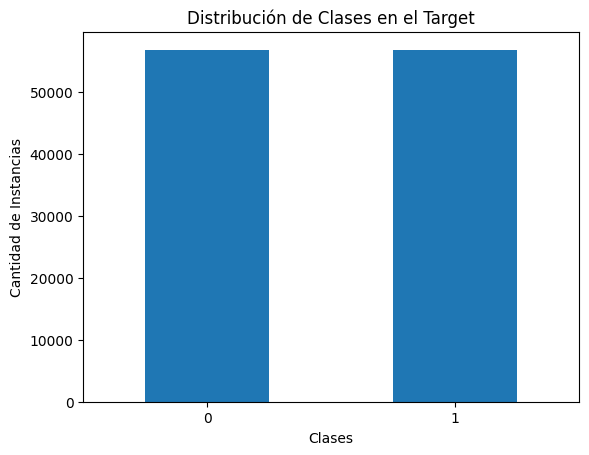


Proporciones de clases:
heart_attack
0    0.5
1    0.5
Name: count, dtype: float64

El target está balanceado.


In [5]:
import matplotlib.pyplot as plt

# Contar las clases
class_counts = y_train_bal.value_counts()
print("Conteo de clases:")
print(class_counts)

 # Visualizar la distribución
class_counts.plot(kind='bar')
plt.title('Distribución de Clases en el Target')
plt.xlabel('Clases')
plt.ylabel('Cantidad de Instancias')
plt.xticks(rotation=0)  # Rotar etiquetas del eje x si es necesario
plt.show()

 # Calcular la proporción
class_proportions = class_counts / class_counts.sum()
print("\nProporciones de clases:")
print(class_proportions)

 # Evaluar el desbalance
threshold = 0.8  # Umbral para considerar desbalanceo
is_imbalanced = any(class_proportions > threshold)
if is_imbalanced:
     print("\nEl target está desbalanceado.")
else:
     print("\nEl target está balanceado.")

## Normalización de los datos. 

In [6]:
#Normalizacion

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_bal)

X_train_norm = scaler.transform(X_train_bal)
X_train_norm = pd.DataFrame(X_train_norm, index = X_train_bal.index, columns = num_variables)

X_test_norm = scaler.transform(X_test)
X_test_norm = pd.DataFrame(X_test_norm, index = X_test.index, columns = num_variables)

X_train_norm.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening
0,-0.910177,-0.888451,-1.256313,1.945319,-0.630252,-0.469994,-0.928693,-0.552779,0.964719,1.658136,...,-1.044881,-0.244667,-1.475434,1.285656,-0.679285,0.373669,-0.457265,-0.477037,1.088504,0.879231
1,0.196174,1.125555,0.795980,-0.930416,-0.630252,-0.469994,0.072953,-0.552779,-0.765905,-0.603087,...,-0.639265,1.391005,-0.791316,-0.148058,-0.995734,-1.421876,2.186917,-0.477037,-0.918692,-1.137358
2,-1.165489,1.125555,0.795980,0.507451,-0.630252,-0.469994,2.126329,-0.552779,-0.209633,-0.603087,...,-0.639265,2.822219,-0.863329,0.671207,1.478323,-0.503700,-0.457265,-0.477037,1.088504,0.879231
3,0.451486,1.125555,0.795980,0.507451,1.586667,-0.469994,-0.477952,-0.552779,-0.889521,1.658136,...,0.847994,-0.960274,-1.259397,-1.479364,0.874193,0.740939,-0.457265,-0.477037,1.088504,0.879231
4,0.281278,-0.888451,0.795980,0.507451,1.586667,-0.469994,1.049559,-0.552779,0.593871,-0.603087,...,-0.436457,0.675399,1.117010,-0.967323,1.650932,-1.748339,-0.457265,-0.477037,1.088504,0.879231


## Entrenar modelo LightGBM. 

In [8]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 38170, number of negative: 56843
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1631
[LightGBM] [Info] Number of data points in the train set: 95013, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.401734 -> initscore=-0.398243
[LightGBM] [Info] Start training from score -0.398243


LGBMClassifier(random_state=42)

In [9]:
y_pred_lgbm = model.predict(X_test)
y_pred_lgbm

array([0, 1, 0, ..., 0, 0, 0], shape=(63342,))

In [11]:
from sklearn.metrics import recall_score

recall_score_lgbm = recall_score(y_test, y_pred_lgbm)

print(f'Resultados LightGBM:')
print(f'Recall_score: {recall_score_lgbm}')

Resultados LightGBM:
Recall_score: 0.616398878844104


## Optimización de Hiperparámetros. 

In [12]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LGBMClassifier(random_state=42))
])

# 2. Hiperparámetros adaptados para RandomizedSearchCV
lgb_grid_rs_bal = {
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.05, 0.1],
    'clf__boosting_type': ['gbdt'],
    'clf__num_leaves': [15, 31],
    'clf__n_estimators': [100, 200]
}

# 3. Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. RandomizedSearchCV optimizando recall
lgbm_model_rs_bal = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=lgb_grid_rs_bal,
    n_iter=20,  # Puedes reducir si va muy lento
    scoring="recall",  # o "f1" si cambias de prioridad
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# 5. Entrenamiento sobre datos originales (no balanceados por fuera)
lgbm_model_rs_bal.fit(X_train, y_train)

# 6. Resultados
print("Mejores hiperparámetros:", lgbm_model_rs_bal.best_params_)
print("Mejor recall promedio en validación:", lgbm_model_rs_bal.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 45474, number of negative: 45474
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1631
[LightGBM] [Info] Number of data points in the train set: 90948, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 45474, number of negative: 45474
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1627
[LightGBM] [Info] Number of data points in the train set: 90948, number of used features: 27
[LightGBM] 

In [13]:
y_pred_rsbal = lgbm_model_rs_bal.predict(X_test)
y_pred_rsbal

array([0, 1, 0, ..., 0, 0, 0], shape=(63342,))

## Modelo entrenado con los mejores hiperparámetros. 

In [14]:
# Obtener los mejores hiperparámetros
mejores_hiperparametros = lgbm_model_rs_bal.best_params_

# Mostrar resultados
print("Mejores hiperparámetros encontrados:")
for param, valor in mejores_hiperparametros.items():
    print(f"{param}: {valor}")

Mejores hiperparámetros encontrados:
clf__num_leaves: 15
clf__n_estimators: 100
clf__max_depth: 7
clf__learning_rate: 0.05
clf__boosting_type: gbdt


In [15]:
from imblearn.pipeline import Pipeline as ImbPipeline

best_params = lgbm_model_rs_bal.best_params_

# Filtrar solo los parámetros del modelo (quitar el prefijo 'model__')
model_params = {k.replace('model__', ''): v for k, v in best_params.items()}

In [16]:
final_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(**model_params, random_state=42))
])

# Entrenarlo con TODO el conjunto de entrenamiento
final_pipeline.fit(X_train, y_train)

[LightGBM] [Warning] Unknown parameter: clf__max_depth
[LightGBM] [Warning] Unknown parameter: clf__boosting_type
[LightGBM] [Warning] Unknown parameter: clf__n_estimators
[LightGBM] [Warning] Unknown parameter: clf__num_leaves
[LightGBM] [Warning] Unknown parameter: clf__learning_rate
[LightGBM] [Warning] Unknown parameter: clf__max_depth
[LightGBM] [Warning] Unknown parameter: clf__boosting_type
[LightGBM] [Warning] Unknown parameter: clf__n_estimators
[LightGBM] [Warning] Unknown parameter: clf__num_leaves
[LightGBM] [Warning] Unknown parameter: clf__learning_rate
[LightGBM] [Info] Number of positive: 56843, number of negative: 56843
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1637
[LightGBM] [Info] Number of data points in the train set: 113686, number of used features: 27
[

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 LGBMClassifier(clf__boosting_type='gbdt',
                                clf__learning_rate=0.05, clf__max_depth=7,
                                clf__n_estimators=100, clf__num_leaves=15,
                                random_state=42))])

In [17]:
y_pred_rs_bal = final_pipeline.predict(X_test)
y_pred_rs_bal

[LightGBM] [Warning] Unknown parameter: clf__max_depth
[LightGBM] [Warning] Unknown parameter: clf__n_estimators
[LightGBM] [Warning] Unknown parameter: clf__num_leaves
[LightGBM] [Warning] Unknown parameter: clf__learning_rate
[LightGBM] [Warning] Unknown parameter: clf__boosting_type


array([0, 1, 0, ..., 1, 0, 0], shape=(63342,))

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rs_bal))

              precision    recall  f1-score   support

           0       0.78      0.71      0.75     38011
           1       0.62      0.70      0.66     25331

    accuracy                           0.71     63342
   macro avg       0.70      0.71      0.70     63342
weighted avg       0.72      0.71      0.71     63342



## Guardar modelo. 

In [19]:
import pickle

with open('./models/model_LGBMClassifier_Heart_Atack_App.sav', 'wb') as file:pickle.dump(final_pipeline, file)